# Laboratorio 7 — Forecasting sobre ETTh1 con LSTM y Transformer desde cero

CC3092 Deep Learning, UVG.

Implementamos un sistema de forecasting sobre el dataset ETTh1 (Electricity
Transformer Temperature) usando dos arquitecturas construidas con tensores
PyTorch puros (sin `nn.LSTM` ni `nn.MultiheadAttention` ni `nn.LayerNorm`):
un LSTM many-to-one y un Transformer encoder con self-attention temporal.
Evaluamos ambas sobre dos horizontes de predicción, H = 24 y H = 48 horas,
prediciendo la temperatura del aceite (`OT`) del transformador.

In [1]:
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## Task 1 — Preprocesamiento y análisis exploratorio

### Task 1.1 — Descarga y preprocesamiento

In [2]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

print(f"Filas totales: {data.shape[0]}, columnas: {data.shape[1]}")
print(f"OT: min={OT.min():.3f}, max={OT.max():.3f}, media={OT.mean():.3f}")

Filas totales: 17420, columnas: 8
OT: min=-4.080, max=46.007, media=13.325


**a. Normalización de `OT`.** Restamos la media y dividimos por la
desviación estándar calculadas sobre la serie completa, guardando `mu` y
`sigma` para poder desnormalizar las predicciones al momento de evaluar.

In [3]:
mu = OT.mean()
sigma = OT.std()
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"OT_norm: media={OT_norm.mean().item():.4f}, std={OT_norm.std().item():.4f}")

mu=13.3247, sigma=8.5667
OT_norm: media=-0.0000, std=1.0000


**b. Split temporal 60/20/20.** El split es un bloque temporal
contiguo por conjunto (sin mezcla aleatoria), ya que en series de tiempo
mezclar aleatoriamente rompería la dependencia temporal y filtraría
información del futuro hacia el pasado (data leakage).

In [4]:
N = len(OT_norm)
n_train = int(0.6 * N)
n_val = int(0.2 * N)

OT_train = OT_norm[:n_train]
OT_val   = OT_norm[n_train:n_train + n_val]
OT_test  = OT_norm[n_train + n_val:]

print(f"N total={N}")
print(f"train={len(OT_train)} ({len(OT_train)/N:.1%}), "
      f"val={len(OT_val)} ({len(OT_val)/N:.1%}), "
      f"test={len(OT_test)} ({len(OT_test)/N:.1%})")

N total=17420
train=10452 (60.0%), val=3484 (20.0%), test=3484 (20.0%)


**c. `make_windows(series, L, H)`.** Construye pares
$(X^{(t)}, y^{(t)})$ con $X^{(t)} = (x_{t-L+1}, \dots, x_t)$ y
$y^{(t)} = x_{t+H}$, usando `unfold` para vectorizar la construcción de
ventanas deslizantes.

In [5]:
def make_windows(series, L, H):
    """Construye ventanas (X, y) de una serie 1D.

    Parametros
    ----------
    series : Tensor o ndarray 1D
    L : int, longitud de la ventana de historia
    H : int, horizonte de prediccion

    Retorna
    -------
    X : Tensor (N, L)
    y : Tensor (N,)
    """
    if isinstance(series, np.ndarray):
        series = torch.from_numpy(series).float()
    N = series.shape[0]
    n_samples = N - L - H + 1
    X = series.unfold(0, L, 1)[:n_samples]        # (n_samples, L)
    y = series[L + H - 1: L + H - 1 + n_samples]    # (n_samples,)
    return X, y

L = 96

X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

for name, X, y in [("tr_24", X_tr_24, y_tr_24), ("vl_24", X_vl_24, y_vl_24),
                    ("te_24", X_te_24, y_te_24), ("tr_48", X_tr_48, y_tr_48),
                    ("vl_48", X_vl_48, y_vl_48), ("te_48", X_te_48, y_te_48)]:
    print(f"X_{name}: {tuple(X.shape)}, y_{name}: {tuple(y.shape)}")

X_tr_24: (10333, 96), y_tr_24: (10333,)
X_vl_24: (3365, 96), y_vl_24: (3365,)
X_te_24: (3365, 96), y_te_24: (3365,)
X_tr_48: (10309, 96), y_tr_48: (10309,)
X_vl_48: (3341, 96), y_vl_48: (3341,)
X_te_48: (3341, 96), y_te_48: (3341,)


> **Nota:** L = 96 corresponde a cuatro días de historia horaria.
A continuación usamos la ACF para justificar si ese valor es apropiado.

### Task 1.2 — ACF manual

In [6]:
def acf_manual(series, max_lag):
    """Autocorrelacion de una serie 1D para lags 0..max_lag."""
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xbar = x.mean()
    denom = np.sum((x - xbar) ** 2) / N
    acf = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        num = np.sum((x[k:] - xbar) * (x[:N - k] - xbar)) / (N - k)
        acf[k] = num / denom
    return acf

max_lag = 96
acf_values = acf_manual(OT_train.numpy(), max_lag)
print(f"ACF[0]={acf_values[0]:.4f}, ACF[24]={acf_values[24]:.4f}, "
      f"ACF[48]={acf_values[48]:.4f}, ACF[96]={acf_values[96]:.4f}")

ACF[0]=1.0000, ACF[24]=0.9250, ACF[48]=0.8763, ACF[96]=0.8489


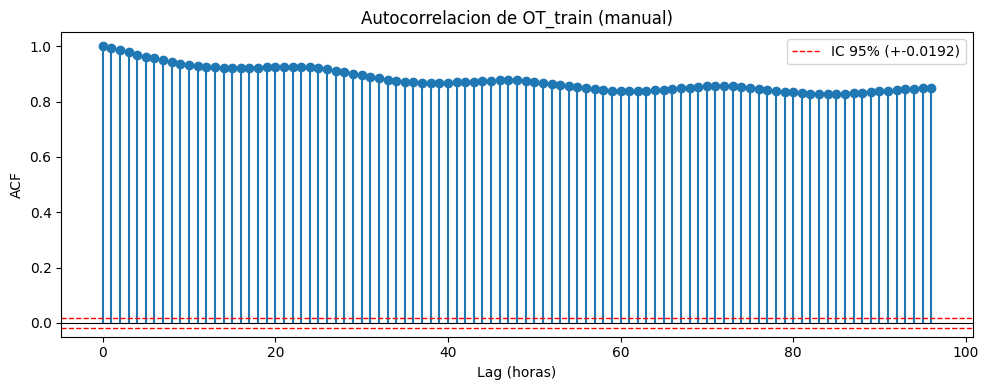

In [7]:
N_train = len(OT_train)
ci = 1.96 / np.sqrt(N_train)

plt.figure(figsize=(10, 4))
plt.stem(range(max_lag + 1), acf_values, basefmt=" ")
plt.axhline(ci, color="red", linestyle="--", linewidth=1, label=f"IC 95% (+-{ci:.4f})")
plt.axhline(-ci, color="red", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (horas)")
plt.ylabel("ACF")
plt.title("Autocorrelacion de OT_train (manual)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# El lag=1 siempre gana si comparamos valores crudos (es solo inercia de
# corto plazo). Lo que realmente delata la periodicidad diaria son los
# maximos locales de la ACF: puntos donde sube respecto al lag anterior y
# baja respecto al siguiente.
local_max_lags = [k for k in range(1, len(acf_values) - 1)
                   if acf_values[k] > acf_values[k - 1] and acf_values[k] > acf_values[k + 1]]

print(f"Valor crudo mas alto tras lag 0: lag=1, ACF={acf_values[1]:.4f} (solo inercia de corto plazo)")
print("Maximos locales de la ACF (huella de la periodicidad diaria):")
for lag in local_max_lags:
    print(f"  lag={lag:>3d}  ACF={acf_values[lag]:.4f}")

Valor crudo mas alto tras lag 0: lag=1, ACF=0.9923 (solo inercia de corto plazo)
Maximos locales de la ACF (huella de la periodicidad diaria):
  lag= 22  ACF=0.9262
  lag= 47  ACF=0.8770
  lag= 72  ACF=0.8572


**Pregunta a.** Identificar el lag con el segundo pico más alto de la
ACF (después de lag 0) e interpretarlo en términos de periodicidad.

Esto conecta directo con el patrón que vimos al graficar la ACF, porque
aunque el lag 1 tiene el valor más alto después de lag 0 (0.9923), eso es
solo la inercia típica de una serie horaria que casi no cambia de una hora
a la siguiente, así que el pico que en realidad nos interesa es el primer
máximo local que aparece después de esa caída inicial, y ese está en el
lag 22 con ACF=0.9262, seguido de otros dos máximos locales casi igual de
espaciados en el lag 47 (ACF=0.8770) y el lag 72 (ACF=0.8572), y nos parece
que esos tres picos, separados entre sí por unos 24-25 lags, son la huella
de la periodicidad diaria de la temperatura del aceite, ya que el
transformador se calienta y se enfría siguiendo el ciclo de carga eléctrica
y la temperatura ambiente de cada día, y aunque el pico no cae exactamente
en el lag 24 sino un poco antes, en el fondo se debe a que la ACF todavía
viene bajando de la fuerte autocorrelación de corto plazo antes de que el
efecto estacional logre revertir la tendencia.

**Pregunta b.** Justificar, con referencia explícita a los valores de la
ACF, si L = 96 es una elección apropiada.

Con esos mismos valores nos deja pensando que L=96 sí es una elección
razonable para la ventana, porque en 96 horas alcanzamos a cubrir los tres
máximos locales que encontramos (lag 22, 47 y 72), o sea que el modelo ve
prácticamente cuatro ciclos diarios completos antes de hacer la predicción,
y eso le da información suficiente para aprender el patrón estacional en
vez de quedarse solo con la inercia de corto plazo, y además la ACF en el
lag 96 todavía vale 0.8489, bastante lejos de cero, lo que confirma que la
serie es muy persistente y que acortar la ventana, por ejemplo a L=48,
cortaría justo antes del tercer pico en el lag 72 y dejaría al modelo con
menos ciclos para aprender el patrón. Ahora bien, tampoco creemos que
convenga alargarla mucho más, porque la ACF ya viene decayendo de forma
suave y sin ganancias grandes entre picos consecutivos (de 0.9262 a 0.8770
a 0.8572), así que agregar más historia empezaría a sumar costo
computacional sin aportar mucha correlación lineal adicional, y en el
fondo L=96 logra un balance entre capturar varios ciclos diarios completos
y no cargar al LSTM o al Transformer con secuencias innecesariamente
largas.

### Verificación Task 1

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)
